<a href="https://colab.research.google.com/github/SSapunar/AICheques/blob/main/Copia_de_Lab3_RegresionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Regresion Logistica para Clasificacion (MNIST)

En este laboratorio intermedio-practico conectaremos ideas de **Lab 2 (regresion)** con el salto a **Lab 4 (Perceptron/MLP)**.

Trabajaremos con tres niveles:

1. Clasificacion binaria: **"0" vs "no-0"**.
2. Extension multiclase con **10 modelos One-vs-Rest (OVR) explicitos**.
3. Comparacion con **regresion logistica multinomial directa**.

Al final incluimos una extension opcional avanzada con embeddings tipo CLIP.

## Objetivos de aprendizaje

- Comprender por que una regresion lineal no es adecuada para clasificacion.
- Implementar regresion logistica binaria en un caso real.
- Construir una solucion multiclase por OVR explicito (10 regresiones binarias).
- Comparar OVR vs multinomial y discutir ventajas/desventajas.
- Preparar el puente conceptual para Perceptron y modelos no lineales (Lab 4).

## Ruta del laboratorio

1. Setup, carga y exploracion de MNIST.
2. Bloque binario 0 vs no-0 (modelo, metricas e interpretacion).
3. Bloque multiclase con OVR explicito (10 modelos).
4. Bloque multinomial directo.
5. Comparacion de resultados y conclusiones.
6. Ejercicios de practica + respuestas.
7. Extension opcional avanzada (CLIP embeddings).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

np.random.seed(42)
sns.set_style("whitegrid")

## 1) Carga y exploracion de MNIST

In [21]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32)
Y = mnist.target.astype(np.int64)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Clases:", np.unique(Y))

X shape: (70000, 784)
Y shape: (70000,)
Clases: [0 1 2 3 4 5 6 7 8 9]


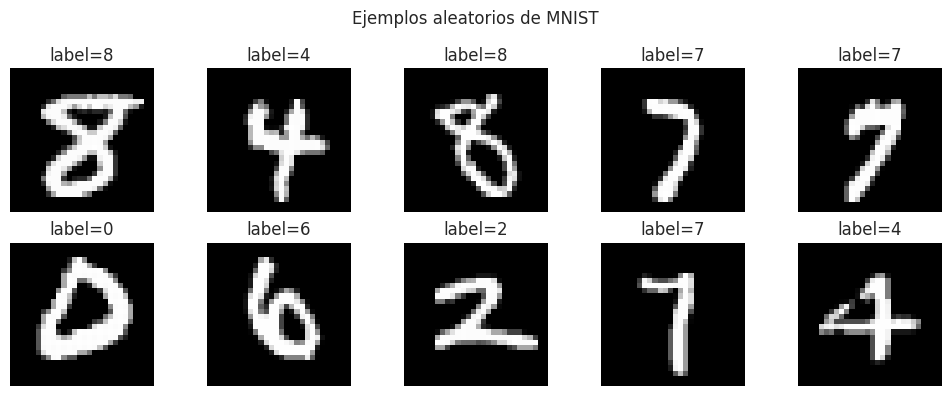

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
idx = np.random.choice(len(X), size=10, replace=False)
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"label={Y[i]}")
    ax.axis("off")
plt.suptitle("Ejemplos aleatorios de MNIST")
plt.tight_layout()
plt.show()

## 2) Problema binario: "0" vs "no-0"

Definimos una variable objetivo binaria:

- clase positiva: imagen del digito 0
- clase negativa: cualquier otro digito (1-9)

Esto nos permite entender a fondo el flujo de una clasificacion binaria antes de pasar a multiclase.

In [24]:
Y_binario = (Y == 0).astype(np.int64)
Y_binario

array([0, 1, 0, ..., 0, 0, 0])

In [25]:
X_train, X_test, Y_train_binario, Y_test_binario = train_test_split(
    X, Y_binario, test_size=0.3, random_state=42, stratify=Y_binario
)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, Y_train_binario.shape)
print("Test:", X_test_scaled.shape, Y_test_binario.shape)

Train: (49000, 784) (49000,)
Test: (21000, 784) (21000,)


In [27]:
print("Valores iguales a 0 en Train:", Y_train_binario.sum())
print("Valores iguales a 0 en Test:", Y_test_binario.sum())

Valores iguales a 0 en Train: 4832
Valores iguales a 0 en Test: 2071


In [28]:
clf_bin = LogisticRegression(random_state=42)
clf_bin.fit(X_train_scaled, Y_train_binario)

Y_pred_binario = clf_bin.predict(X_test_scaled)
Y_prob_binario = clf_bin.predict_proba(X_test_scaled)[:, 1]

In [9]:
Y_pred_binario

array([0, 0, 0, ..., 1, 0, 0])

In [10]:
Y_prob_binario

array([1.88171925e-07, 2.84759852e-11, 2.40396325e-07, ...,
       9.84715497e-01, 1.85762647e-08, 2.24945260e-10])

In [11]:
acc = accuracy_score(Y_test_binario, Y_pred_binario)
prec = precision_score(Y_test_binario, Y_pred_binario)
rec = recall_score(Y_test_binario, Y_pred_binario)
f1 = f1_score(Y_test_binario, Y_pred_binario)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")

Accuracy : 0.9905
Precision: 0.9496
Recall   : 0.9546
F1       : 0.9521


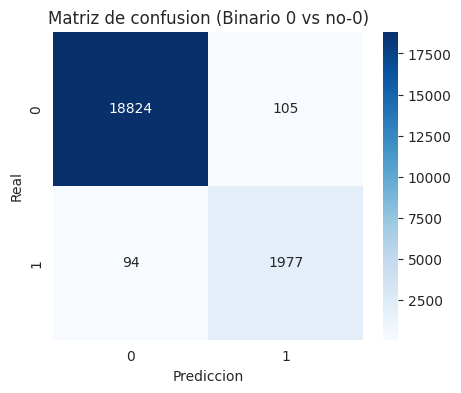

In [12]:
cm_bin = confusion_matrix(Y_test_binario, Y_pred_binario)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion (Binario 0 vs no-0)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

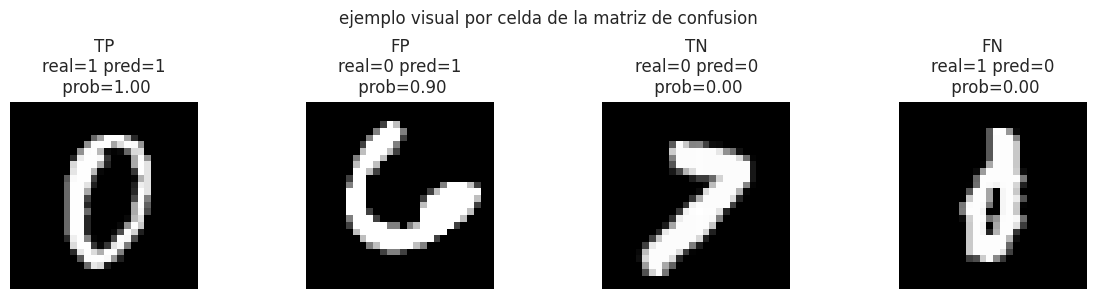

In [13]:
# Visualizar un ejemplo de cada categoria: TP, FP, TN, FN
idx_tp = np.where((Y_test_binario == 1) & (Y_pred_binario == 1))[0]
idx_fp = np.where((Y_test_binario == 0) & (Y_pred_binario == 1))[0]
idx_tn = np.where((Y_test_binario == 0) & (Y_pred_binario == 0))[0]
idx_fn = np.where((Y_test_binario == 1) & (Y_pred_binario == 0))[0]

casos = [
    ("TP", idx_tp),
    ("FP", idx_fp),
    ("TN", idx_tn),
    ("FN", idx_fn),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (nombre, idxs) in zip(axes, casos):
    if len(idxs) == 0:
        ax.axis("off")
        ax.set_title(f"{nombre}\n(sin ejemplos)")
        continue

    i = idxs[0]
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(
        f"{nombre}\nreal={Y_test_binario[i]} pred={Y_pred_binario[i]}\n prob={Y_prob_binario[i]:.2f}"
    )
    ax.axis("off")

plt.suptitle("ejemplo visual por celda de la matriz de confusion")
plt.tight_layout()
plt.show()

In [14]:
# Estudio visual de threshold
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    y_pred_t = (Y_prob_binario >= t).astype(int)
    rows.append(
        {
            "threshold": t,
            "accuracy": accuracy_score(Y_test_binario, y_pred_t),
            "precision": precision_score(Y_test_binario, y_pred_t, zero_division=0),
            "recall": recall_score(Y_test_binario, y_pred_t, zero_division=0),
            "f1": f1_score(Y_test_binario, y_pred_t, zero_division=0),
        }
    )
df_thr = pd.DataFrame(rows)
df_thr

,threshold,accuracy,precision,recall,f1
0,0.05,0.980238,0.841584,0.985031,0.907675
1,0.10,0.985000,0.880746,0.980686,0.928033
2,0.15,0.987476,0.903571,0.977306,0.938993
3,0.20,0.988381,0.914662,0.972960,0.942911
4,0.25,0.989000,0.923183,0.969097,0.945583
5,0.30,0.989571,0.929898,0.967166,0.948166
6,0.35,0.990048,0.936679,0.964268,0.950274
7,0.40,0.990190,0.940066,0.961854,0.950835
8,0.45,0.990333,0.943495,0.959440,0.951401
9,0.50,0.990524,0.949568,0.954611,0.952083


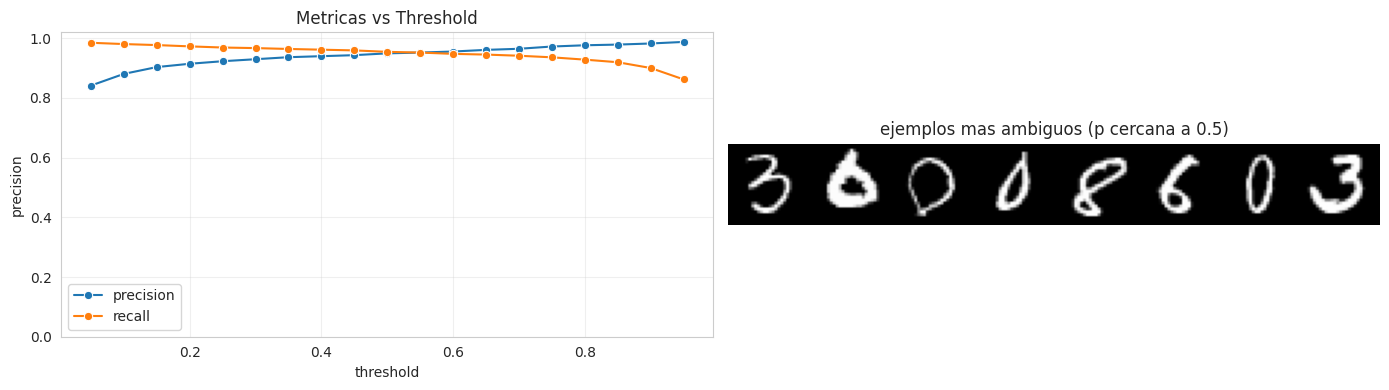

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: curvas de metricas vs threshold
for m in ["precision", "recall"]:
    sns.lineplot(data=df_thr, x="threshold", y=m, marker="o", ax=axes[0], label=m)
axes[0].set_title("Metricas vs Threshold")
axes[0].set_ylim(0.0, 1.02)
axes[0].grid(alpha=0.3)

# Panel 2: ejemplos ambiguos cercanos al threshold 0.5
dist = np.abs(Y_prob_binario - 0.5)
idx_amb = np.argsort(dist)[:8]
thumb = np.hstack([X_test[i].reshape(28, 28) for i in idx_amb])
axes[1].imshow(thumb, cmap="gray")
axes[1].set_title("ejemplos mas ambiguos (p cercana a 0.5)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3) Extension multiclase: One-vs-Rest (OVR) explicito

En OVR entrenamos **10 modelos binarios**:

- modelo 0: "0" vs resto
- modelo 1: "1" vs resto
- ...
- modelo 9: "9" vs resto

Para predecir una imagen, calculamos la probabilidad de cada clase y elegimos la mayor.

In [16]:
X_train_mc, X_test_mc, Y_train_mc, Y_test_mc = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

scaler_mc = StandardScaler()
X_train_mc = scaler_mc.fit_transform(X_train_mc)
X_test_mc = scaler_mc.transform(X_test_mc)

classes = np.unique(Y_train_mc)
ovr_models = {}

In [17]:
for c in classes:
    Y_train_c = (Y_train_mc == c).astype(np.int64)
    model_c = LogisticRegression(max_iter=300, random_state=42)
    model_c.fit(X_train_mc, Y_train_c)
    ovr_models[c] = model_c

In [18]:
probs_ovr = np.column_stack([
    ovr_models[c].predict_proba(X_test_mc)[:, 1] for c in classes
])

Y_pred_ovr = probs_ovr.argmax(axis=1)

acc_ovr = accuracy_score(Y_test_mc, Y_pred_ovr)
print(f"Accuracy OVR explicito: {acc_ovr:.4f}")

Accuracy OVR explicito: 0.9134


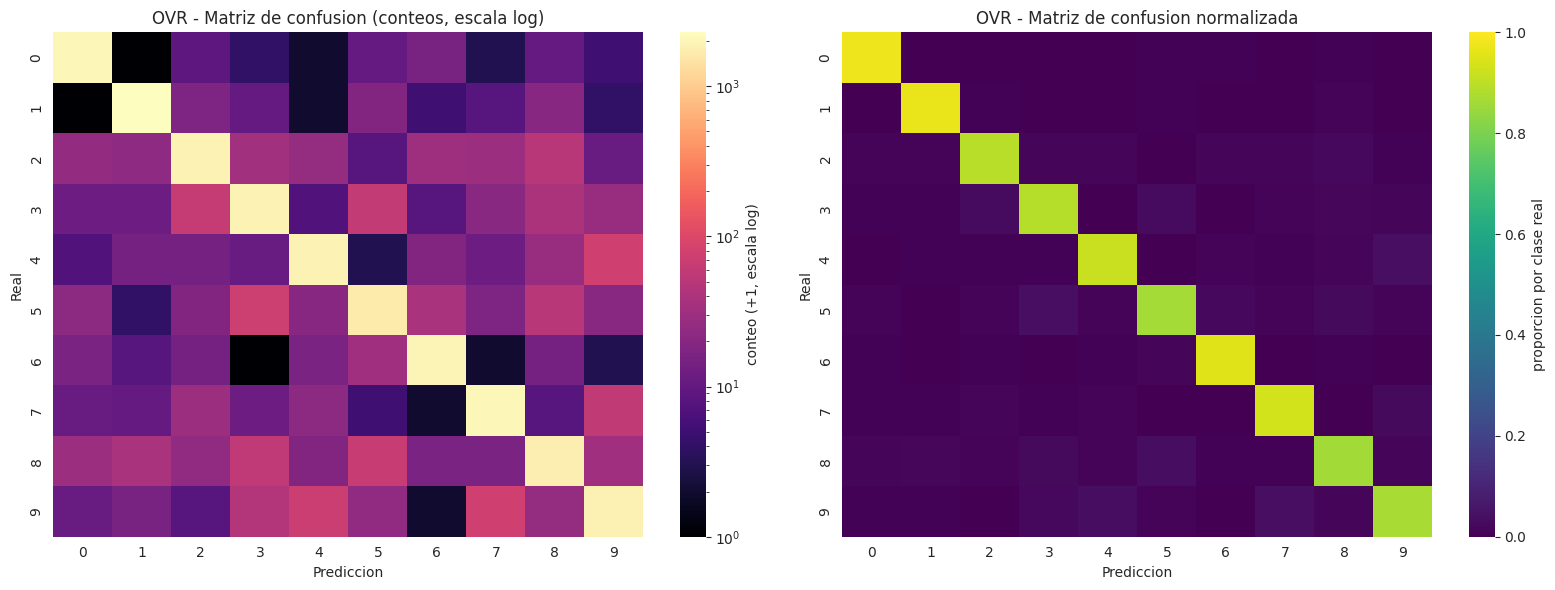

In [19]:
cm_ovr = confusion_matrix(Y_test_mc, Y_pred_ovr)
cm_ovr_norm = cm_ovr / cm_ovr.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Conteos en escala log para resaltar errores fuera de la diagonal
sns.heatmap(
    cm_ovr + 1,
    cmap="magma",
    norm=LogNorm(vmin=1, vmax=(cm_ovr + 1).max()),
    cbar_kws={"label": "conteo (+1, escala log)"},
    ax=axes[0],
)
axes[0].set_title("OVR - Matriz de confusion (conteos, escala log)")
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")

# Version normalizada por fila para comparar errores relativos
sns.heatmap(
    cm_ovr_norm,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "proporcion por clase real"},
    ax=axes[1],
)
axes[1].set_title("OVR - Matriz de confusion normalizada")
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## 5) Puente hacia Lab 4 (Perceptron)

La regresion logistica y el perceptron comparten un nucleo lineal:

- ambos calculan una combinacion lineal de features
- ambos producen fronteras de decision lineales

Diferencias clave:

- la logistica modela probabilidades y permite analisis de umbrales
- el perceptron clasico actualiza pesos de otra forma y no entrega probabilidad calibrada

En Lab 4 usaremos esta base para introducir modelos con mayor capacidad de representacion (Perceptron/MLP).

## 6) Ejercicios de practica

### A) Binario alternativo
Repite el experimento binario, pero ahora con "1" vs "no-1".

- Entrena y evalua.
- Compara tus metricas con el caso "0" vs "no-0".
- Escribe 2 conclusiones.

## 7) CLIP como extractor de embeddings + Regresion Logistica

En esta seccion usaremos CLIP **solo como modelo de vision** para transformar cada imagen de MNIST en un vector de embedding.

Luego entrenaremos una regresion logistica multinomial sobre esos embeddings y compararemos contra un baseline de regresion logistica entrenada sobre pixeles.

Objetivo:
- Evaluar si una representacion preentrenada (embeddings CLIP) mejora metricas frente a pixeles crudos/escalados.
- Mantener el mismo esquema de evaluacion: accuracy, precision macro, recall macro y f1 macro.

> Nota practica: extraer embeddings para todo MNIST puede tardar bastante. Por eso usamos un subset configurable.

In [20]:
# Dependencias y funciones para extraer embeddings CLIP de imagen
# pip install transformers torch pillow

import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(model_id)
clip_model = CLIPModel.from_pretrained(model_id).to(device)
clip_model.eval()

# Recuperar pixeles en escala original (si X_train_mc y X_test_mc fueron estandarizados)
X_train_mc_raw = scaler_mc.inverse_transform(X_train_mc)
X_test_mc_raw = scaler_mc.inverse_transform(X_test_mc)

def _maybe_project(x, model):
    """Aplica visual_projection solo si la dimension de entrada coincide."""
    if not torch.is_tensor(x):
        return x
    proj = getattr(model, "visual_projection", None)
    if proj is None:
        return x

    in_features = getattr(proj, "in_features", None)
    if in_features is None:
        return x

    # Evita doble proyeccion (causa mismatch 512 vs 768, por ejemplo)
    if x.shape[-1] == in_features:
        return proj(x)
    return x

def _to_tensor_features(out, model):
    """Convierte distintas salidas posibles de CLIP a un tensor [B, D]."""
    if torch.is_tensor(out):
        return _maybe_project(out, model)

    if isinstance(out, (tuple, list)) and len(out) > 0:
        return _to_tensor_features(out[0], model)

    # Caso comun: BaseModelOutputWithPooling
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        pooled = out.pooler_output
        return _maybe_project(pooled, model)

    # Fallback con CLS token si existe last_hidden_state
    if hasattr(out, "last_hidden_state") and out.last_hidden_state is not None:
        cls_tok = out.last_hidden_state[:, 0, :]
        return _maybe_project(cls_tok, model)

    raise TypeError(f"Salida de CLIP no soportada: {type(out)}")

def _image_features_compat(model, pixel_values):
    """Obtiene features de imagen con fallback para diferencias entre versiones de transformers."""
    try:
        # Algunas versiones devuelven tensor, otras objetos estructurados
        out = model.get_image_features(pixel_values=pixel_values)
    except Exception:
        # Fallback: usar rama visual
        out = model.vision_model(pixel_values=pixel_values)

    return _to_tensor_features(out, model)

def obtener_embeddings_clip(X_array, batch_size=128):
    """Extrae embeddings de imagen con CLIP y devuelve matriz [N, D]."""
    embs = []
    with torch.no_grad():
        for i in range(0, len(X_array), batch_size):
            batch = X_array[i:i + batch_size]
            images = []
            for img_flat in batch:
                arr = np.clip(img_flat.reshape(28, 28), 0, 255).astype(np.uint8)
                images.append(Image.fromarray(arr, mode="L").convert("RGB"))

            inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
            feats = _image_features_compat(clip_model, inputs["pixel_values"])

            feats = torch.nn.functional.normalize(feats, p=2, dim=1)
            embs.append(feats.cpu().numpy())

    return np.vstack(embs)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# 1) Definir subset para experimento CLIP (ajustable)
N_TRAIN_CLIP = 4000
N_TEST_CLIP = 1000

X_train_clip_in = X_train_mc_raw[:N_TRAIN_CLIP]
Y_train_clip = Y_train_mc[:N_TRAIN_CLIP]
X_test_clip_in = X_test_mc_raw[:N_TEST_CLIP]
Y_test_clip = Y_test_mc[:N_TEST_CLIP]

# 2) Baseline: logistica multinomial sobre pixeles escalados
X_train_base = X_train_mc[:N_TRAIN_CLIP]
X_test_base = X_test_mc[:N_TEST_CLIP]

clf_base = LogisticRegression(
    max_iter=400,
    random_state=42,
    multi_class="multinomial",
    solver="lbfgs",
)
clf_base.fit(X_train_base, Y_train_clip)
Y_pred_base = clf_base.predict(X_test_base)

# 3) Embeddings CLIP + logistica multinomial
X_train_clip_emb = obtener_embeddings_clip(X_train_clip_in, batch_size=128)
X_test_clip_emb = obtener_embeddings_clip(X_test_clip_in, batch_size=128)

clf_clip_lr = LogisticRegression(
    max_iter=500,
    random_state=42,
    multi_class="multinomial",
    solver="lbfgs",
)
clf_clip_lr.fit(X_train_clip_emb, Y_train_clip)
Y_pred_clip = clf_clip_lr.predict(X_test_clip_emb)

# 4) Comparar metricas
def metricas_multiclase(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

m_base = metricas_multiclase(Y_test_clip, Y_pred_base)
m_clip = metricas_multiclase(Y_test_clip, Y_pred_clip)

comparacion_clip = pd.DataFrame([
    {"modelo": "LogReg sobre pixeles", **m_base},
    {"modelo": "CLIP embeddings + LogReg", **m_clip},
]).round(4)

display(comparacion_clip)

# 5) Matrices de confusion para inspeccion visual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    confusion_matrix(Y_test_clip, Y_pred_base),
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Baseline: LogReg sobre pixeles")
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")

sns.heatmap(
    confusion_matrix(Y_test_clip, Y_pred_clip),
    cmap="magma",
    ax=axes[1],
)
axes[1].set_title("CLIP embeddings + LogReg")
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()